## Import Required Libraries

In [40]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from scipy.stats import multivariate_normal
from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, adjusted_rand_score
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Part 1: GMM Class Implementation from Numpy
### GMM Class with EM Algorithm

In [41]:
class GMM():
    def __init__(self, k, dim, init_mu=None, init_sigma=None, init_pi=None, colors=None):
        '''
        Define a model with known number of clusters and dimensions.
        input:
            - k: Number of Gaussian clusters
            - dim: Dimension 
            - init_mu: initial value of mean of clusters (k, dim)
                       (default) random from uniform[-10, 10]
            - init_sigma: initial value of covariance matrix of clusters (k, dim, dim)
                          (default) Identity matrix for each cluster
            - init_pi: initial value of cluster weights (k,)
                       (default) equal value to all cluster i.e. 1/k
            - colors: Color value for plotting each cluster (k, 3)
                      (default) random from uniform[0, 1]
        '''
        self.k = k
        self.dim = dim
        if(init_mu is None):
            init_mu = random.rand(k, dim)*20 - 10
        self.mu = init_mu
        if(init_sigma is None):
            init_sigma = np.zeros((k, dim, dim))
            for i in range(k):
                init_sigma[i] = np.eye(dim)
        self.sigma = init_sigma
        if(init_pi is None):
            init_pi = np.ones(self.k)/self.k
        self.pi = init_pi
        if(colors is None):
            colors = random.rand(k, 3)
            for i in range(k):
                colors[i, 2] = i/k
        self.colors = colors
    
    def init_em(self, X):
        '''
        Initialization for EM algorithm.
        input:
            - X: data (batch_size, dim)
        '''
        self.data = X
        self.num_points = X.shape[0]
        self.z = np.zeros((self.num_points, self.k))
    
    def e_step(self):
        '''
        E-step of EM algorithm.
        '''
        for i in range(self.k):
            self.z[:, i] = self.pi[i] * multivariate_normal.pdf(self.data, mean=self.mu[i], cov=self.sigma[i], allow_singular=True)
        self.z /= self.z.sum(axis=1, keepdims=True)
    
    def m_step(self):
        '''
        M-step of EM algorithm.
        '''
        sum_z = self.z.sum(axis=0)
        self.pi = sum_z / self.num_points
        self.mu = np.matmul(self.z.T, self.data)
        self.mu /= sum_z[:, None]
        for i in range(self.k):
            j = np.expand_dims(self.data, axis=1) - self.mu[i]
            s = np.matmul(j.transpose([0, 2, 1]), j)
            self.sigma[i] = np.matmul(s.transpose(1, 2, 0), self.z[:, i] )
            self.sigma[i] /= sum_z[i]
            # Add small regularization to prevent singular covariance matrices
            self.sigma[i] += np.eye(self.dim) * 1e-6
            
    def log_likelihood(self, X):
        '''
        Compute the log-likelihood of X under current parameters
        input:
            - X: Data (batch_size, dim)
        output:
            - log-likelihood of X: Sum_n Sum_k log(pi_k * N( X_n | mu_k, sigma_k ))
        '''
        ll = []
        for d in X:
            tot = 0
            for i in range(self.k):
                tot += self.pi[i] * multivariate_normal.pdf(d, mean=self.mu[i], cov=self.sigma[i], allow_singular=True)
            ll.append(np.log(tot))
        return np.sum(ll)
    
    def plot_gaussian(self, mean, cov, ax, n_std=3.0, facecolor='none', **kwargs):
        '''
        Utility function to plot one Gaussian from mean and covariance.
        '''
        pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
        ell_radius_x = np.sqrt(1 + pearson)
        ell_radius_y = np.sqrt(1 - pearson)
        ellipse = Ellipse((0, 0),
            width=ell_radius_x * 2,
            height=ell_radius_y * 2,
            facecolor=facecolor,
            **kwargs)
        scale_x = np.sqrt(cov[0, 0]) * n_std
        mean_x = mean[0]
        scale_y = np.sqrt(cov[1, 1]) * n_std
        mean_y = mean[1]
        transf = transforms.Affine2D() \
            .rotate_deg(45) \
            .scale(scale_x, scale_y) \
            .translate(mean_x, mean_y)
        ellipse.set_transform(transf + ax.transData)
        return ax.add_patch(ellipse)

    def draw(self, ax, n_std=2.0, facecolor='none', **kwargs):
        '''
        Function to draw the Gaussians.
        Note: Only for two-dimensional dataset
        '''
        if(self.dim != 2):
            print("Drawing available only for 2D case.")
            return
        for i in range(self.k):
            self.plot_gaussian(self.mu[i], self.sigma[i], ax, n_std=n_std, edgecolor=self.colors[i], **kwargs)
    
    def predict(self, X):
        '''
        Predict cluster labels for data X.
        '''
        z = np.zeros((X.shape[0], self.k))
        for i in range(self.k):
            z[:, i] = self.pi[i] * multivariate_normal.pdf(X, mean=self.mu[i], cov=self.sigma[i], allow_singular=True)
        return np.argmax(z, axis=1)

### Data Generation Function

In [42]:
def gen_data(k=3, dim=2, points_per_cluster=200, lim=[-20, 20]):
    '''
    Generates data from a random mixture of Gaussians in a given range.
    Will also plot the points in case of 2D.
    input:
        - k: Number of Gaussian clusters
        - dim: Dimension of generated points
        - points_per_cluster: Number of points to be generated for each cluster
        - lim: Range of mean values
    output:
        - X: Generated points (points_per_cluster*k, dim)
    '''
    x = []
    mean = random.rand(k, dim)*(lim[1]-lim[0]) + lim[0]
    for i in range(k):
        cov = random.rand(dim, dim+10)
        cov = np.matmul(cov, cov.T)
        _x = np.random.multivariate_normal(mean[i], cov, points_per_cluster)
        x += list(_x)
    x = np.array(x)
    if(dim == 2):
        fig = plt.figure(figsize=(8, 6))
        ax = fig.gca()
        ax.scatter(x[:,0], x[:,1], s=3, alpha=0.4)
        ax.autoscale(enable=True)
        plt.title('Generated Synthetic Data')
        plt.show()
    return x

## Example 1: GMM on Synthetic 2D Data
### Generate Random 2D Data with 3 Clusters

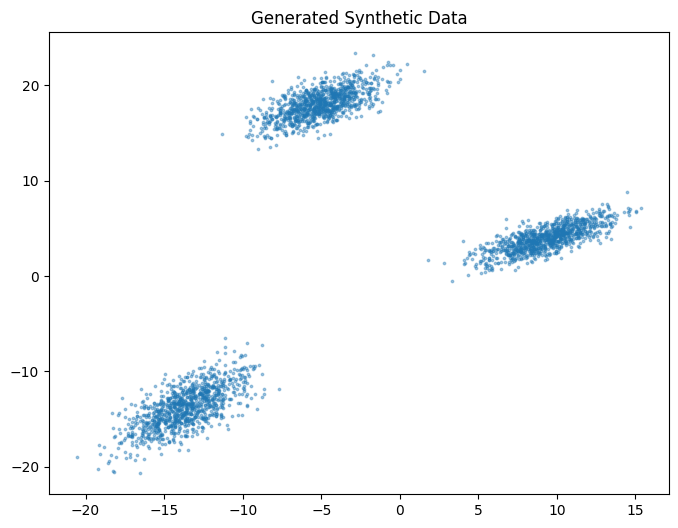

In [43]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate random 2D data with 3 clusters
X_synthetic = gen_data(k=3, dim=2, points_per_cluster=1000)

### Training GMM using EM Algorithm

In [44]:
# Create a Gaussian Mixture Model
gmm_synthetic = GMM(3, 2)

# Initialize EM algo with data
gmm_synthetic.init_em(X_synthetic)

# Number of iterations
num_iters = 20

# Saving log-likelihood
log_likelihood = [gmm_synthetic.log_likelihood(X_synthetic)]

print(f"Iteration 0, log-likelihood: {log_likelihood[0]:.4f}")

# Training loop
for e in range(num_iters):
    # E-step
    gmm_synthetic.e_step()
    # M-step
    gmm_synthetic.m_step()
    # Computing log-likelihood
    log_likelihood.append(gmm_synthetic.log_likelihood(X_synthetic))
    print(f"Iteration {e+1}, log-likelihood: {log_likelihood[-1]:.4f}")

Iteration 0, log-likelihood: -239983.1941
Iteration 1, log-likelihood: -14323.9909
Iteration 1, log-likelihood: -14323.9909
Iteration 2, log-likelihood: -14322.9570
Iteration 2, log-likelihood: -14322.9570
Iteration 3, log-likelihood: -14322.9570
Iteration 3, log-likelihood: -14322.9570
Iteration 4, log-likelihood: -14322.9570
Iteration 4, log-likelihood: -14322.9570
Iteration 5, log-likelihood: -14322.9570
Iteration 5, log-likelihood: -14322.9570
Iteration 6, log-likelihood: -14322.9570
Iteration 6, log-likelihood: -14322.9570
Iteration 7, log-likelihood: -14322.9570
Iteration 7, log-likelihood: -14322.9570
Iteration 8, log-likelihood: -14322.9570
Iteration 8, log-likelihood: -14322.9570
Iteration 9, log-likelihood: -14322.9570
Iteration 9, log-likelihood: -14322.9570
Iteration 10, log-likelihood: -14322.9570
Iteration 10, log-likelihood: -14322.9570
Iteration 11, log-likelihood: -14322.9570
Iteration 11, log-likelihood: -14322.9570
Iteration 12, log-likelihood: -14322.9570
Iteration 

### Visualize Training Progress

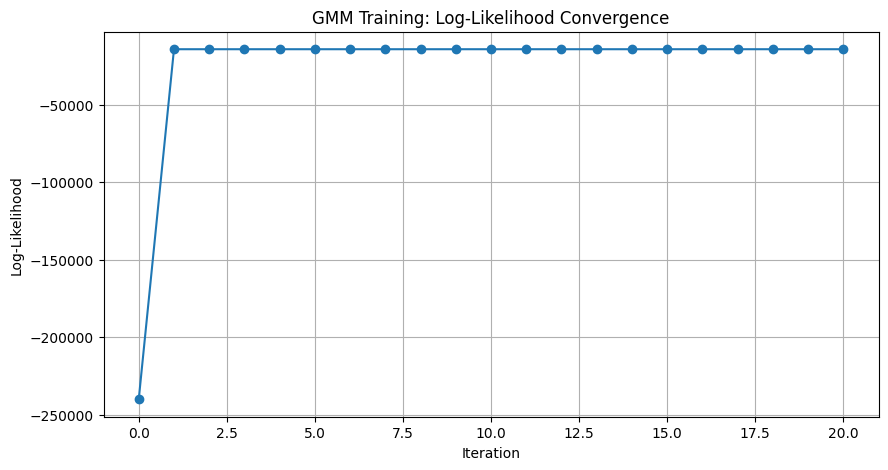

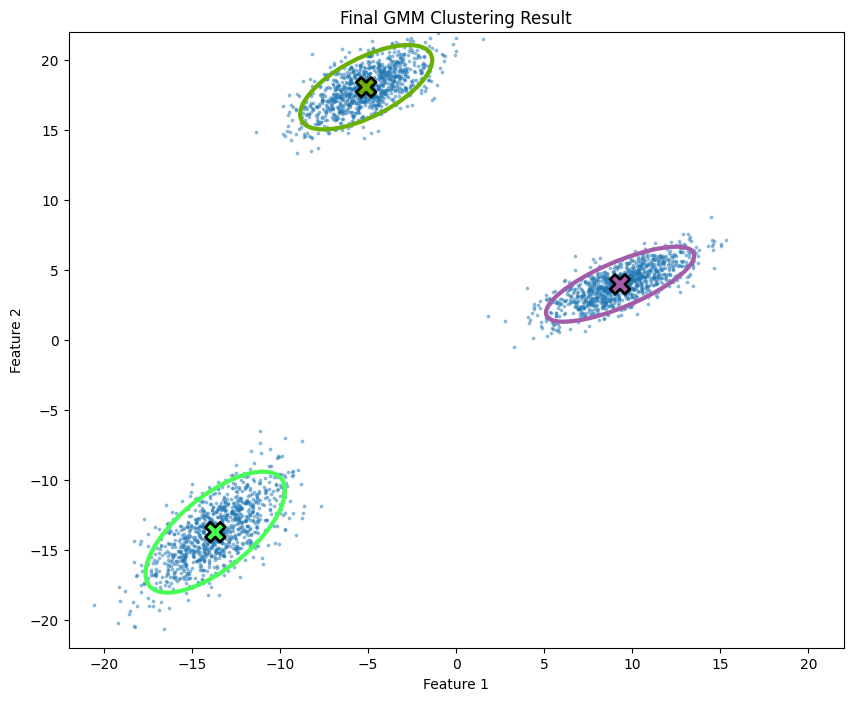

In [17]:
# Plot log-likelihood convergence
plt.figure(figsize=(10, 5))
plt.plot(range(len(log_likelihood)), log_likelihood, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('GMM Training: Log-Likelihood Convergence')
plt.grid(True)
plt.show()

# Plot final result
fig = plt.figure(figsize=(10, 8))
ax = fig.gca()
ax.scatter(X_synthetic[:, 0], X_synthetic[:, 1], s=3, alpha=0.4)
ax.scatter(gmm_synthetic.mu[:, 0], gmm_synthetic.mu[:, 1], c=gmm_synthetic.colors, s=200, marker='X', edgecolors='black', linewidths=2)
gmm_synthetic.draw(ax, lw=3)
ax.set_xlim((-22, 22))
ax.set_ylim((-22, 22))
plt.title('Final GMM Clustering Result')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Exercise 1: GMM on Iris Dataset
### Load and Explore Iris Dataset

In [18]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data  # Features only (without target labels)
y_iris = iris.target  # True labels

print(f"Iris Dataset Shape: {X_iris.shape}")
print(f"Features: {iris.feature_names}")
print(f"Target Names: {iris.target_names}")
print(f"\nFirst 5 samples:")
print(X_iris[:5])
print(f"\nTrue labels (first 10): {y_iris[:10]}")

Iris Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']

First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

True labels (first 10): [0 0 0 0 0 0 0 0 0 0]


### Apply GMM to Iris Dataset

In [35]:
# Create GMM with 3 clusters (for 3 iris species) and 4 dimensions
gmm_iris = GMM(k=3, dim=4)

# Initialize EM with Iris data
gmm_iris.init_em(X_iris)

# Training
num_iters = 30
log_likelihood_iris = [gmm_iris.log_likelihood(X_iris)]

print("Training GMM on Iris Dataset...")
for e in range(num_iters):
    gmm_iris.e_step()
    gmm_iris.m_step()
    log_likelihood_iris.append(gmm_iris.log_likelihood(X_iris))
    if (e + 1) % 5 == 0:
        print(f"Iteration {e+1}, log-likelihood: {log_likelihood_iris[-1]:.4f}")

print(f"\nFinal log-likelihood: {log_likelihood_iris[-1]:.4f}")

Training GMM on Iris Dataset...
Iteration 5, log-likelihood: -216.3620
Iteration 10, log-likelihood: -190.9115
Iteration 15, log-likelihood: -190.9115
Iteration 10, log-likelihood: -190.9115
Iteration 15, log-likelihood: -190.9115
Iteration 20, log-likelihood: -190.9115
Iteration 25, log-likelihood: -190.9115
Iteration 30, log-likelihood: -190.9115

Final log-likelihood: -190.9115
Iteration 20, log-likelihood: -190.9115
Iteration 25, log-likelihood: -190.9115
Iteration 30, log-likelihood: -190.9115

Final log-likelihood: -190.9115


### Predict Cluster Labels and Compare with True Labels

Predicted labels (first 20): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
True labels (first 20):      [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Confusion Matrix:
[[49  1  0]
 [ 0  0 50]
 [ 0  0 50]]


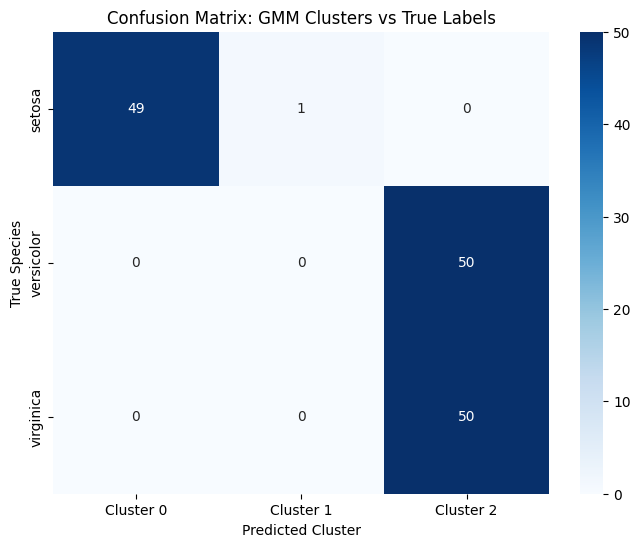


Adjusted Rand Index: 0.5584
(ARI ranges from -1 to 1, where 1 means perfect clustering)


In [45]:
# Get predicted cluster labels
y_pred_gmm = gmm_iris.predict(X_iris)

print("Predicted labels (first 20):", y_pred_gmm[:20])
print("True labels (first 20):     ", y_iris[:20])

# Since cluster labels may not match directly with true labels, we need to find the best mapping
# Calculate confusion matrix to see the correspondence
conf_matrix = confusion_matrix(y_iris, y_pred_gmm)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
            yticklabels=iris.target_names)
plt.title('Confusion Matrix: GMM Clusters vs True Labels')
plt.ylabel('True Species')
plt.xlabel('Predicted Cluster')
plt.show()

# Calculate Adjusted Rand Index (measures clustering quality)
ari_score = adjusted_rand_score(y_iris, y_pred_gmm)
print(f"\nAdjusted Rand Index: {ari_score:.4f}")
print("(ARI ranges from -1 to 1, where 1 means perfect clustering)")

### Visualize GMM Results on Iris (2D Projection)

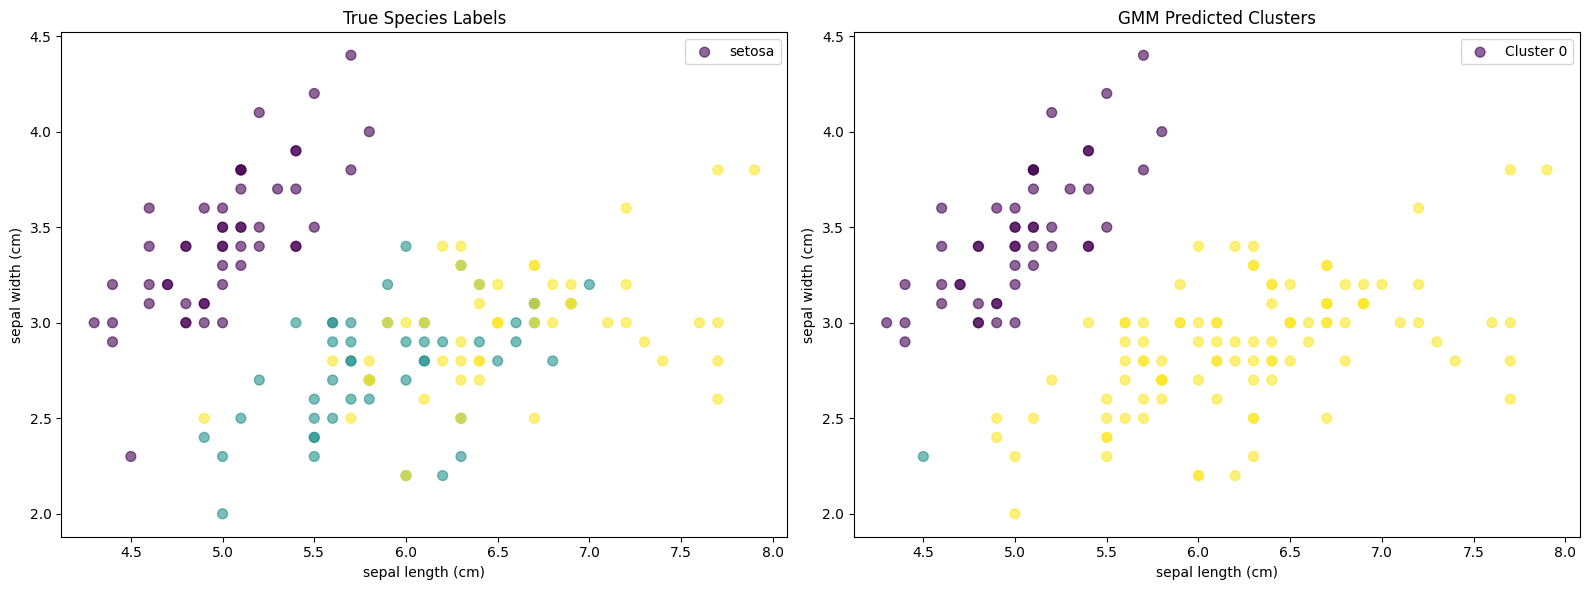

In [46]:
# Visualize using first two features for 2D plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: True labels
scatter1 = axes[0].scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, cmap='viridis', s=50, alpha=0.6)
axes[0].set_xlabel(iris.feature_names[0])
axes[0].set_ylabel(iris.feature_names[1])
axes[0].set_title('True Species Labels')
legend1 = axes[0].legend(*scatter1.legend_elements(), labels=iris.target_names, loc='upper right')

# Plot 2: GMM predicted clusters
scatter2 = axes[1].scatter(X_iris[:, 0], X_iris[:, 1], c=y_pred_gmm, cmap='viridis', s=50, alpha=0.6)
axes[1].set_xlabel(iris.feature_names[0])
axes[1].set_ylabel(iris.feature_names[1])
axes[1].set_title('GMM Predicted Clusters')
legend2 = axes[1].legend(*scatter2.legend_elements(), labels=['Cluster 0', 'Cluster 1', 'Cluster 2'], loc='upper right')

plt.tight_layout()
plt.show()

### Analysis and Interpretation

In [47]:
print("=" * 60)
print("ANALYSIS: GMM ON IRIS DATASET")
print("=" * 60)
print(f"\n1. Dataset Information:")
print(f"   - Total samples: {X_iris.shape[0]}")
print(f"   - Features: {X_iris.shape[1]}")
print(f"   - True classes: {len(np.unique(y_iris))}")

print(f"\n2. GMM Model:")
print(f"   - Number of components: 3")
print(f"   - Training iterations: {num_iters}")
print(f"   - Final log-likelihood: {log_likelihood_iris[-1]:.4f}")

print(f"\n3. Clustering Quality:")
print(f"   - Adjusted Rand Index: {ari_score:.4f}")

print(f"\n4. Cluster Distribution:")
for i in range(3):
    count = np.sum(y_pred_gmm == i)
    print(f"   - Cluster {i}: {count} samples ({count/len(y_pred_gmm)*100:.1f}%)")

print(f"\n5. Interpretation:")
print("   The confusion matrix shows how well GMM clusters correspond to")
print("   the true species. GMM can identify the natural groupings in the")
print("   Iris dataset, though cluster labels may not directly match species names.")
print("   The Adjusted Rand Index measures the similarity between predicted")
print("   clusters and true labels, accounting for chance.")
print("=" * 60)

ANALYSIS: GMM ON IRIS DATASET

1. Dataset Information:
   - Total samples: 150
   - Features: 4
   - True classes: 3

2. GMM Model:
   - Number of components: 3
   - Training iterations: 20
   - Final log-likelihood: -190.9115

3. Clustering Quality:
   - Adjusted Rand Index: 0.5584

4. Cluster Distribution:
   - Cluster 0: 49 samples (32.7%)
   - Cluster 1: 1 samples (0.7%)
   - Cluster 2: 100 samples (66.7%)

5. Interpretation:
   The confusion matrix shows how well GMM clusters correspond to
   the true species. GMM can identify the natural groupings in the
   Iris dataset, though cluster labels may not directly match species names.
   The Adjusted Rand Index measures the similarity between predicted
   clusters and true labels, accounting for chance.


## Exercise 2: K-means Comparison on Synthetic Data
### Apply K-means to the Same Synthetic Data

In [48]:
# Apply K-means clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_kmeans = kmeans.fit_predict(X_synthetic)

print("K-means clustering completed.")
print(f"Cluster centers:\n{kmeans.cluster_centers_}")
print(f"\nInertia (sum of squared distances): {kmeans.inertia_:.2f}")

K-means clustering completed.
Cluster centers:
[[  9.31066358   3.96512861]
 [-13.6684595  -13.74404378]
 [ -5.10170054  18.03367906]]

Inertia (sum of squared distances): 20585.70


### Get GMM Predictions for Comparison

In [49]:
# Get GMM predictions
y_pred_gmm_synthetic = gmm_synthetic.predict(X_synthetic)

print("GMM predictions obtained.")
print(f"GMM cluster centers:\n{gmm_synthetic.mu}")

GMM predictions obtained.
GMM cluster centers:
[[ -5.10170054  18.03367906]
 [-13.6684595  -13.74404378]
 [  9.31066358   3.96512861]]


### Side-by-Side Visualization

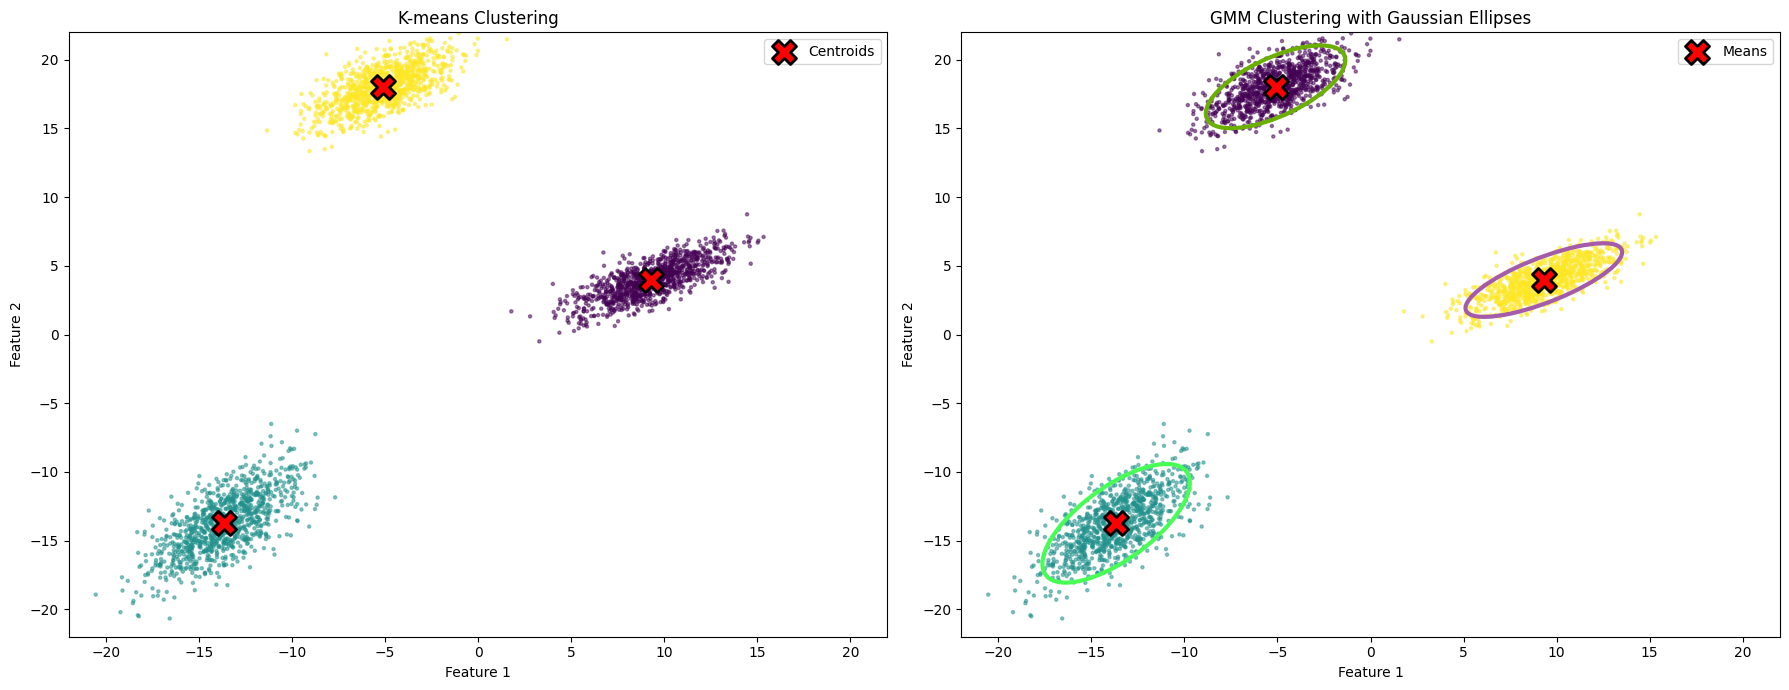

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: K-means results
scatter1 = axes[0].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_pred_kmeans, cmap='viridis', s=5, alpha=0.5)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                c='red', s=300, marker='X', edgecolors='black', linewidths=2, label='Centroids')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title('K-means Clustering')
axes[0].legend()
axes[0].set_xlim((-22, 22))
axes[0].set_ylim((-22, 22))

# Plot 2: GMM results
scatter2 = axes[1].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_pred_gmm_synthetic, cmap='viridis', s=5, alpha=0.5)
axes[1].scatter(gmm_synthetic.mu[:, 0], gmm_synthetic.mu[:, 1], 
                c='red', s=300, marker='X', edgecolors='black', linewidths=2, label='Means')
gmm_synthetic.draw(axes[1], lw=3)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].set_title('GMM Clustering with Gaussian Ellipses')
axes[1].legend()
axes[1].set_xlim((-22, 22))
axes[1].set_ylim((-22, 22))

plt.tight_layout()
plt.show()

### Comparison Analysis

In [27]:
# Calculate agreement between K-means and GMM
ari_kmeans_gmm = adjusted_rand_score(y_pred_kmeans, y_pred_gmm_synthetic)

print("=" * 80)
print("COMPARISON: K-MEANS VS GMM ON SYNTHETIC DATA")
print("=" * 80)

print("\n1. K-MEANS CHARACTERISTICS:")
print("   - Algorithm: Hard clustering (each point belongs to exactly one cluster)")
print("   - Cluster shape: Assumes spherical clusters")
print("   - Distance metric: Euclidean distance to centroids")
print(f"   - Inertia: {kmeans.inertia_:.2f}")
print("   - Limitations: Cannot capture elliptical or non-spherical clusters well")

print("\n2. GMM CHARACTERISTICS:")
print("   - Algorithm: Soft clustering (probabilistic assignments)")
print("   - Cluster shape: Can model elliptical clusters with covariance matrices")
print("   - Distance metric: Mahalanobis distance (accounts for covariance)")
print(f"   - Log-likelihood: {log_likelihood[-1]:.2f}")
print("   - Advantages: More flexible, can capture cluster orientation and shape")

print("\n3. AGREEMENT BETWEEN METHODS:")
print(f"   - Adjusted Rand Index: {ari_kmeans_gmm:.4f}")
print("   - This measures how similar the two clustering results are.")

print("\n4. CLUSTER SIZE COMPARISON:")
print("   K-means cluster sizes:")
for i in range(3):
    count = np.sum(y_pred_kmeans == i)
    print(f"     Cluster {i}: {count} samples ({count/len(y_pred_kmeans)*100:.1f}%)")

print("   GMM cluster sizes:")
for i in range(3):
    count = np.sum(y_pred_gmm_synthetic == i)
    print(f"     Cluster {i}: {count} samples ({count/len(y_pred_gmm_synthetic)*100:.1f}%)")

print("\n5. KEY DIFFERENCES EXPLAINED:")
print("   - K-means uses circular decision boundaries (equal variance in all directions)")
print("   - GMM uses elliptical decision boundaries (different variance in each direction)")
print("   - For elongated or rotated clusters, GMM typically performs better")
print("   - K-means is faster and simpler, GMM is more flexible but computationally expensive")

print("\n6. WHEN TO USE EACH METHOD:")
print("   Use K-means when:")
print("   - Clusters are roughly spherical")
print("   - Speed is important")
print("   - Hard assignments are needed")
print("   ")
print("   Use GMM when:")
print("   - Clusters have different shapes/orientations")
print("   - Probabilistic assignments are useful")
print("   - Data comes from a mixture of Gaussian distributions")
print("=" * 80)

COMPARISON: K-MEANS VS GMM ON SYNTHETIC DATA

1. K-MEANS CHARACTERISTICS:
   - Algorithm: Hard clustering (each point belongs to exactly one cluster)
   - Cluster shape: Assumes spherical clusters
   - Distance metric: Euclidean distance to centroids
   - Inertia: 20585.70
   - Limitations: Cannot capture elliptical or non-spherical clusters well

2. GMM CHARACTERISTICS:
   - Algorithm: Soft clustering (probabilistic assignments)
   - Cluster shape: Can model elliptical clusters with covariance matrices
   - Distance metric: Mahalanobis distance (accounts for covariance)
   - Log-likelihood: -14322.96
   - Advantages: More flexible, can capture cluster orientation and shape

3. AGREEMENT BETWEEN METHODS:
   - Adjusted Rand Index: 1.0000
   - This measures how similar the two clustering results are.

4. CLUSTER SIZE COMPARISON:
   K-means cluster sizes:
     Cluster 0: 1000 samples (33.3%)
     Cluster 1: 1000 samples (33.3%)
     Cluster 2: 1000 samples (33.3%)
   GMM cluster sizes:
  

## Example 2: GMM using Sklearn on Shopping Data
### Load and Explore Shopping Data

In [28]:
# Load shopping data
df_shopping = pd.read_csv('data/shopping-data.csv')

print("Shopping Dataset Info:")
print(df_shopping.info())
print("\nFirst 10 rows:")
print(df_shopping.head(10))
print("\nStatistical Summary:")
print(df_shopping.describe())

Shopping Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

First 10 rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           

### Prepare Data for Clustering

Shopping data shape: (200, 2)
Features used: Annual Income (k$) and Spending Score (1-100)


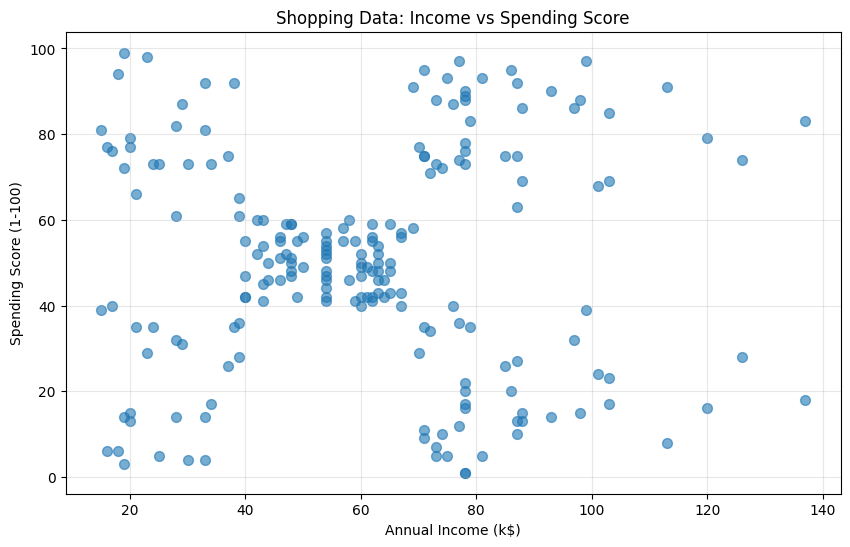

In [29]:
# Extract relevant features: Annual Income and Spending Score
X_shopping = df_shopping[['Annual Income (k$)', 'Spending Score (1-100)']].values

print(f"Shopping data shape: {X_shopping.shape}")
print(f"Features used: Annual Income (k$) and Spending Score (1-100)")

# Visualize the raw data
plt.figure(figsize=(10, 6))
plt.scatter(X_shopping[:, 0], X_shopping[:, 1], alpha=0.6, s=50)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Shopping Data: Income vs Spending Score')
plt.grid(True, alpha=0.3)
plt.show()

### Determine Optimal Number of Clusters

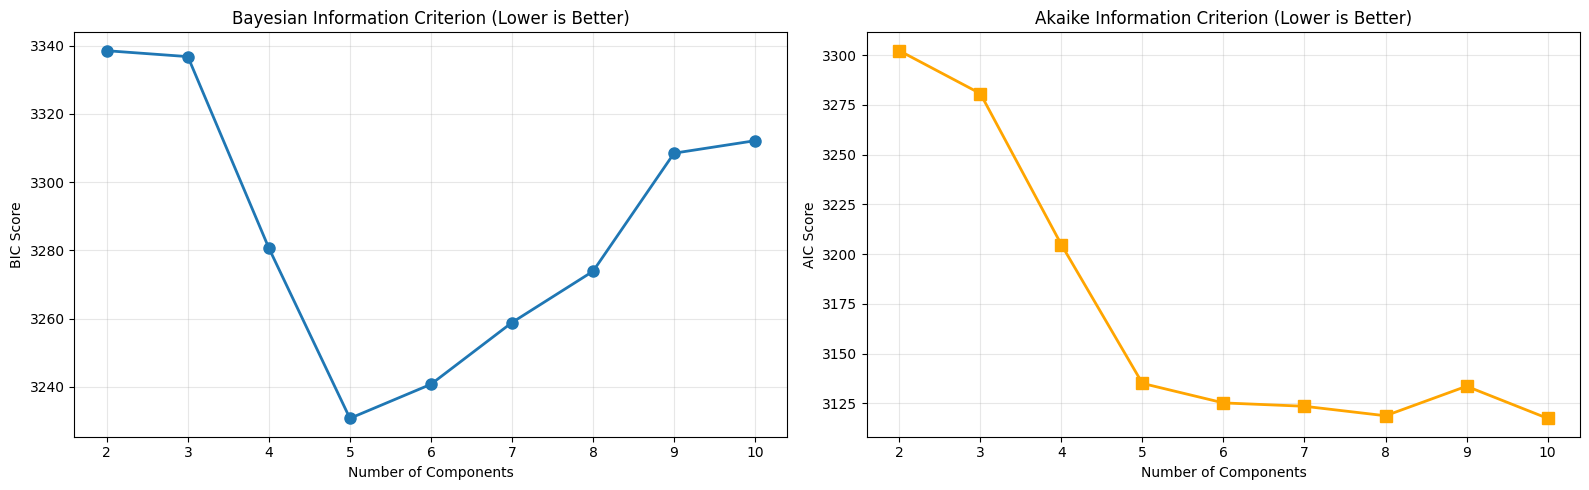

Optimal number of clusters based on BIC: 5
Optimal number of clusters based on AIC: 10


In [50]:
# Try different numbers of clusters and compute BIC and AIC
n_components_range = range(2, 11)
bic_scores = []
aic_scores = []

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42, covariance_type='full')
    gmm.fit(X_shopping)
    bic_scores.append(gmm.bic(X_shopping))
    aic_scores.append(gmm.aic(X_shopping))

# Plot BIC and AIC scores
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(n_components_range, bic_scores, marker='o', linewidth=2, markersize=8)
ax[0].set_xlabel('Number of Components')
ax[0].set_ylabel('BIC Score')
ax[0].set_title('Bayesian Information Criterion (Lower is Better)')
ax[0].grid(True, alpha=0.3)

ax[1].plot(n_components_range, aic_scores, marker='s', linewidth=2, markersize=8, color='orange')
ax[1].set_xlabel('Number of Components')
ax[1].set_ylabel('AIC Score')
ax[1].set_title('Akaike Information Criterion (Lower is Better)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal number of clusters
optimal_bic = n_components_range[np.argmin(bic_scores)]
optimal_aic = n_components_range[np.argmin(aic_scores)]

print(f"Optimal number of clusters based on BIC: {optimal_bic}")
print(f"Optimal number of clusters based on AIC: {optimal_aic}")

### Train GMM with Optimal Number of Clusters

In [31]:
# Use 5 clusters (typical for customer segmentation)
n_clusters_shopping = 5

# Train GMM using sklearn
gmm_shopping = GaussianMixture(n_components=n_clusters_shopping, 
                                covariance_type='full', 
                                random_state=42,
                                n_init=10)

gmm_shopping.fit(X_shopping)
y_pred_shopping = gmm_shopping.predict(X_shopping)
probs = gmm_shopping.predict_proba(X_shopping)

print(f"GMM Training Completed")
print(f"Number of components: {n_clusters_shopping}")
print(f"Converged: {gmm_shopping.converged_}")
print(f"Number of iterations: {gmm_shopping.n_iter_}")
print(f"\nCluster weights (pi): {gmm_shopping.weights_}")
print(f"\nCluster means:\n{gmm_shopping.means_}")

GMM Training Completed
Number of components: 5
Converged: True
Number of iterations: 5

Cluster weights (pi): [0.41333225 0.19669496 0.10353822 0.16552969 0.12090488]

Cluster means:
[[55.710366   49.40699488]
 [86.24063303 82.02037464]
 [25.11748524 80.12817162]
 [88.81300265 16.12462277]
 [27.03119094 22.16675827]]


### Visualize Clustering Results

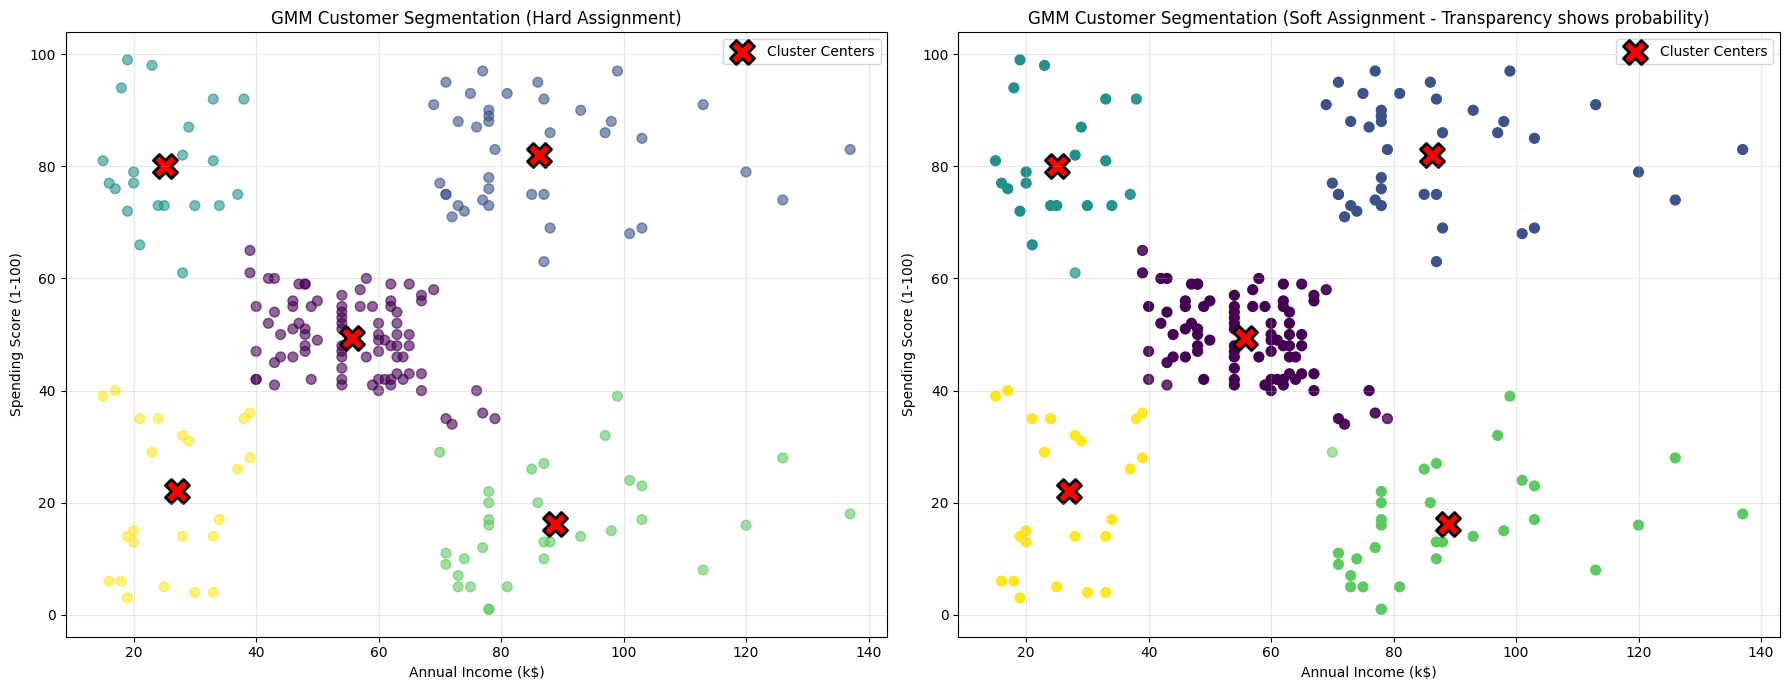

In [51]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Hard clustering
scatter1 = axes[0].scatter(X_shopping[:, 0], X_shopping[:, 1], 
                           c=y_pred_shopping, cmap='viridis', s=50, alpha=0.6)
axes[0].scatter(gmm_shopping.means_[:, 0], gmm_shopping.means_[:, 1],
                c='red', s=300, marker='X', edgecolors='black', linewidths=2, label='Cluster Centers')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('GMM Customer Segmentation (Hard Assignment)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Soft clustering (probability-based coloring)
# Color based on maximum probability
max_probs = np.max(probs, axis=1)
scatter2 = axes[1].scatter(X_shopping[:, 0], X_shopping[:, 1], 
                           c=y_pred_shopping, cmap='viridis', s=50, alpha=max_probs)
axes[1].scatter(gmm_shopping.means_[:, 0], gmm_shopping.means_[:, 1],
                c='red', s=300, marker='X', edgecolors='black', linewidths=2, label='Cluster Centers')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].set_title('GMM Customer Segmentation (Soft Assignment - Transparency shows probability)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Customer Segment Analysis

In [52]:
# Add cluster labels to dataframe
df_shopping['Cluster'] = y_pred_shopping

print("=" * 80)
print("CUSTOMER SEGMENTATION ANALYSIS")
print("=" * 80)

for cluster_id in range(n_clusters_shopping):
    cluster_data = df_shopping[df_shopping['Cluster'] == cluster_id]
    
    print(f"\nCLUSTER {cluster_id}:")
    print(f"  Size: {len(cluster_data)} customers ({len(cluster_data)/len(df_shopping)*100:.1f}%)")
    print(f"  Average Income: ${cluster_data['Annual Income (k$)'].mean():.1f}k")
    print(f"  Average Spending Score: {cluster_data['Spending Score (1-100)'].mean():.1f}")
    print(f"  Income Range: ${cluster_data['Annual Income (k$)'].min():.0f}k - ${cluster_data['Annual Income (k$)'].max():.0f}k")
    print(f"  Spending Range: {cluster_data['Spending Score (1-100)'].min():.0f} - {cluster_data['Spending Score (1-100)'].max():.0f}")
    
    # Characterize the segment
    avg_income = cluster_data['Annual Income (k$)'].mean()
    avg_spending = cluster_data['Spending Score (1-100)'].mean()
    
    if avg_income < 45 and avg_spending < 45:
        segment_type = "Low Income, Low Spending (Careful Spenders)"
    elif avg_income < 45 and avg_spending > 55:
        segment_type = "Low Income, High Spending (Impulsive Buyers)"
    elif avg_income > 65 and avg_spending < 45:
        segment_type = "High Income, Low Spending (Conservative Wealthy)"
    elif avg_income > 65 and avg_spending > 55:
        segment_type = "High Income, High Spending (Premium Customers)"
    else:
        segment_type = "Middle Income, Moderate Spending (Average Customers)"
    
    print(f"  Segment Type: {segment_type}")

print("\n" + "=" * 80)
print("BUSINESS INSIGHTS:")
print("=" * 80)
print("1. Target marketing campaigns to each segment based on their characteristics")
print("2. High income, high spending customers are prime candidates for premium products")
print("3. Low income, high spending customers may benefit from loyalty programs")
print("4. High income, low spending customers need special promotions to increase engagement")
print("5. GMM provides probabilistic membership, useful for customers at segment boundaries")
print("=" * 80)

CUSTOMER SEGMENTATION ANALYSIS

CLUSTER 0:
  Size: 84 customers (42.0%)
  Average Income: $55.6k
  Average Spending Score: 49.4
  Income Range: $39k - $79k
  Spending Range: 34 - 65
  Segment Type: Middle Income, Moderate Spending (Average Customers)

CLUSTER 1:
  Size: 39 customers (19.5%)
  Average Income: $86.5k
  Average Spending Score: 82.1
  Income Range: $69k - $137k
  Spending Range: 63 - 97
  Segment Type: High Income, High Spending (Premium Customers)

CLUSTER 2:
  Size: 21 customers (10.5%)
  Average Income: $25.1k
  Average Spending Score: 80.0
  Income Range: $15k - $38k
  Spending Range: 61 - 99
  Segment Type: Low Income, High Spending (Impulsive Buyers)

CLUSTER 3:
  Size: 33 customers (16.5%)
  Average Income: $88.8k
  Average Spending Score: 16.0
  Income Range: $70k - $137k
  Spending Range: 1 - 39
  Segment Type: High Income, Low Spending (Conservative Wealthy)

CLUSTER 4:
  Size: 23 customers (11.5%)
  Average Income: $26.3k
  Average Spending Score: 20.9
  Income 

### Compare with K-means on Shopping Data

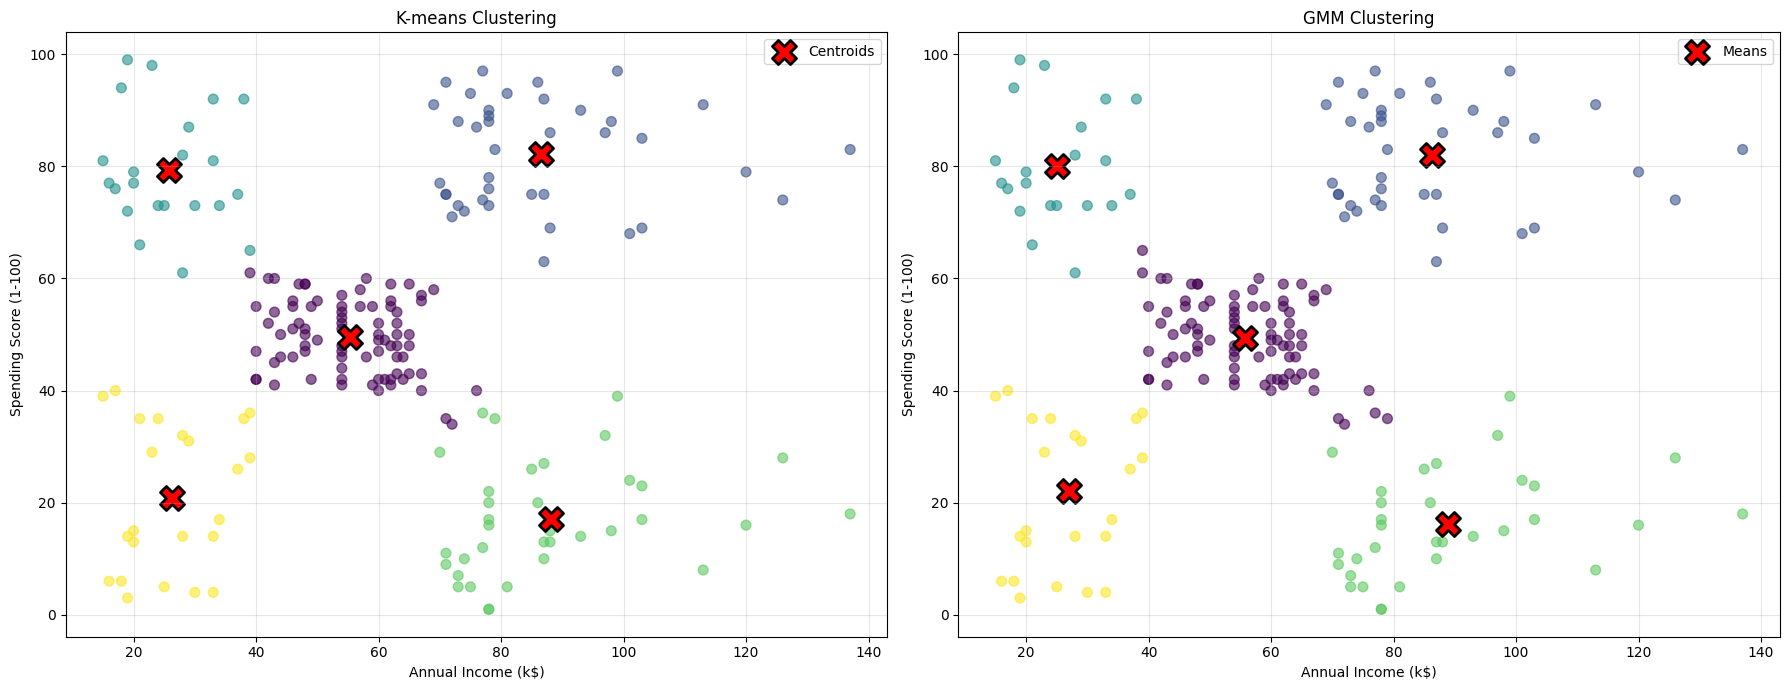

Agreement between K-means and GMM (ARI): 0.9565


In [53]:
# Apply K-means for comparison
kmeans_shopping = KMeans(n_clusters=n_clusters_shopping, random_state=42, n_init=10)
y_pred_kmeans_shopping = kmeans_shopping.fit_predict(X_shopping)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# K-means
scatter1 = axes[0].scatter(X_shopping[:, 0], X_shopping[:, 1], 
                           c=y_pred_kmeans_shopping, cmap='viridis', s=50, alpha=0.6)
axes[0].scatter(kmeans_shopping.cluster_centers_[:, 0], kmeans_shopping.cluster_centers_[:, 1],
                c='red', s=300, marker='X', edgecolors='black', linewidths=2, label='Centroids')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('K-means Clustering')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GMM
scatter2 = axes[1].scatter(X_shopping[:, 0], X_shopping[:, 1], 
                           c=y_pred_shopping, cmap='viridis', s=50, alpha=0.6)
axes[1].scatter(gmm_shopping.means_[:, 0], gmm_shopping.means_[:, 1],
                c='red', s=300, marker='X', edgecolors='black', linewidths=2, label='Means')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].set_title('GMM Clustering')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate agreement
ari_shopping = adjusted_rand_score(y_pred_kmeans_shopping, y_pred_shopping)
print(f"Agreement between K-means and GMM (ARI): {ari_shopping:.4f}")

## Summary and Conclusions

In [54]:
print("=" * 80)
print("WEEK 11 SUMMARY: GAUSSIAN MIXTURE MODEL")
print("=" * 80)

print("\n1. GMM FROM SCRATCH (Example 1):")
print("   - Implemented full GMM class with EM algorithm using NumPy")
print("   - Successfully clustered synthetic 2D data")
print("   - Visualized Gaussian ellipses showing cluster shapes and orientations")
print(f"   - Final log-likelihood: {log_likelihood[-1]:.2f}")

print("\n2. GMM ON IRIS DATASET (Exercise 1):")
print("   - Applied custom GMM to 4D Iris dataset")
print("   - Compared clustering results with true species labels")
print(f"   - Adjusted Rand Index: {ari_score:.4f}")
print("   - GMM successfully identified natural groupings in the data")

print("\n3. K-MEANS VS GMM COMPARISON (Exercise 2):")
print("   - Both algorithms applied to same synthetic data")
print(f"   - Agreement (ARI): {ari_kmeans_gmm:.4f}")
print("   - Key differences:")
print("     * K-means: Hard clustering, spherical clusters, faster")
print("     * GMM: Soft clustering, elliptical clusters, more flexible")
print("   - GMM better captures cluster shape and orientation")

print("\n4. GMM WITH SKLEARN (Example 2):")
print("   - Customer segmentation on shopping data")
print("   - Used BIC/AIC for model selection")
print(f"   - Identified {n_clusters_shopping} distinct customer segments")
print("   - Provided actionable business insights for marketing")

print("\n5. KEY LEARNINGS:")
print("   - EM algorithm: E-step computes responsibilities, M-step updates parameters")
print("   - GMM provides probabilistic cluster assignments (soft clustering)")
print("   - Covariance matrices capture cluster shape and orientation")
print("   - Log-likelihood measures model fit to data")
print("   - GMM is more flexible but more computationally expensive than K-means")
print("   - Model selection criteria (BIC/AIC) help choose optimal number of components")

print("\n6. PRACTICAL APPLICATIONS:")
print("   - Customer segmentation for targeted marketing")
print("   - Image segmentation and computer vision")
print("   - Anomaly detection")
print("   - Density estimation")
print("   - Speech recognition and natural language processing")

print("\n" + "=" * 80)
print("All exercises completed successfully!")
print("=" * 80)

WEEK 11 SUMMARY: GAUSSIAN MIXTURE MODEL

1. GMM FROM SCRATCH (Example 1):
   - Implemented full GMM class with EM algorithm using NumPy
   - Successfully clustered synthetic 2D data
   - Visualized Gaussian ellipses showing cluster shapes and orientations
   - Final log-likelihood: -14322.96

2. GMM ON IRIS DATASET (Exercise 1):
   - Applied custom GMM to 4D Iris dataset
   - Compared clustering results with true species labels
   - Adjusted Rand Index: 0.5584
   - GMM successfully identified natural groupings in the data

3. K-MEANS VS GMM COMPARISON (Exercise 2):
   - Both algorithms applied to same synthetic data
   - Agreement (ARI): 1.0000
   - Key differences:
     * K-means: Hard clustering, spherical clusters, faster
     * GMM: Soft clustering, elliptical clusters, more flexible
   - GMM better captures cluster shape and orientation

4. GMM WITH SKLEARN (Example 2):
   - Customer segmentation on shopping data
   - Used BIC/AIC for model selection
   - Identified 5 distinct cus